In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
import keras
from keras.models import Sequential
from keras.layers import Dense

2026-03-16 19:12:01.461655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773688321.748986      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773688321.827184      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773688322.464965      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773688322.465012      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773688322.465015      17 computation_placer.cc:177] computation placer alr

In [4]:
from sklearn.preprocessing import StandardScaler,LabelBinarizer
from sklearn.utils import shuffle
from sklearn.datasets import load_iris

In [5]:
data=load_iris()
print(data)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [6]:
data=pd.DataFrame(data=np.c_[data['data'],data['target']],columns=data['feature_names']+['target'])
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


<function matplotlib.pyplot.show(close=None, block=None)>

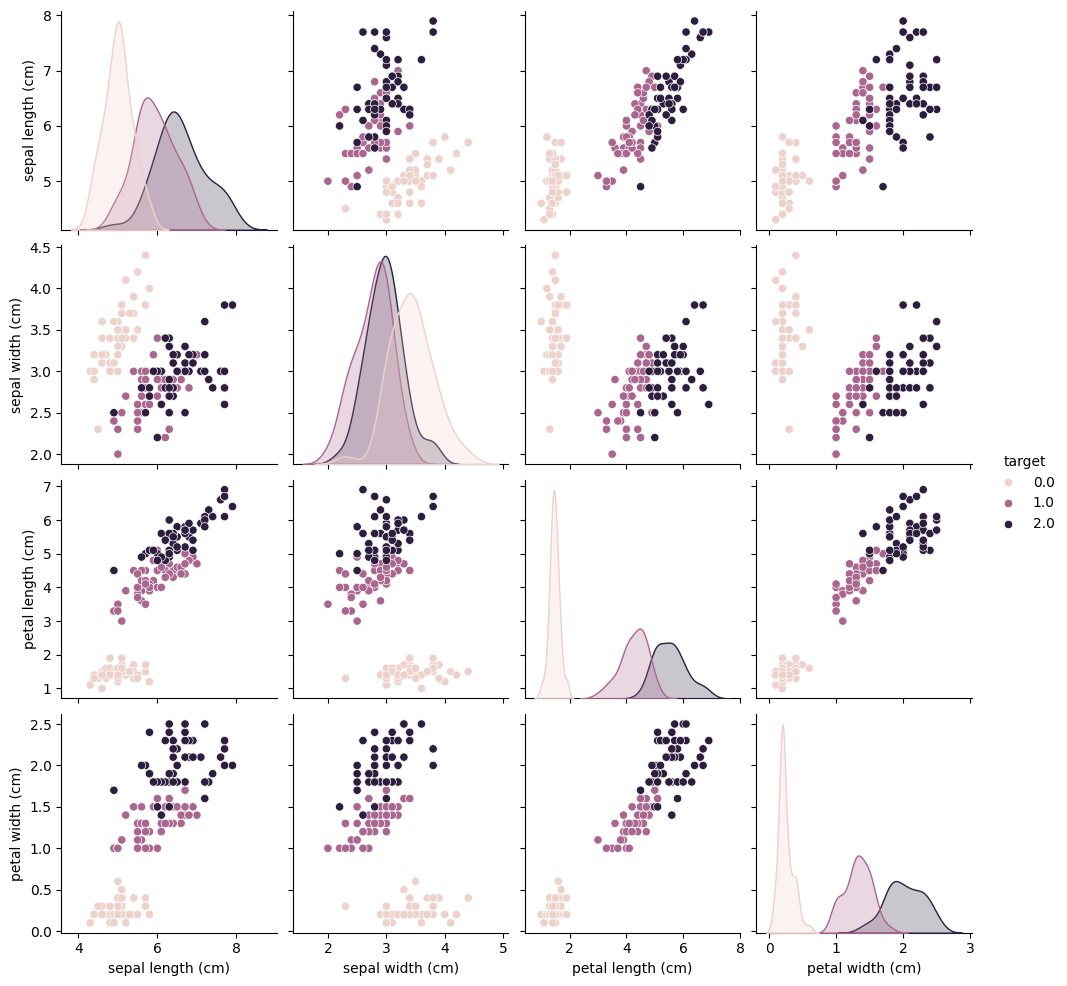

In [7]:
sns.pairplot(data=data[data.columns[0:6]],hue='target')
plt.show

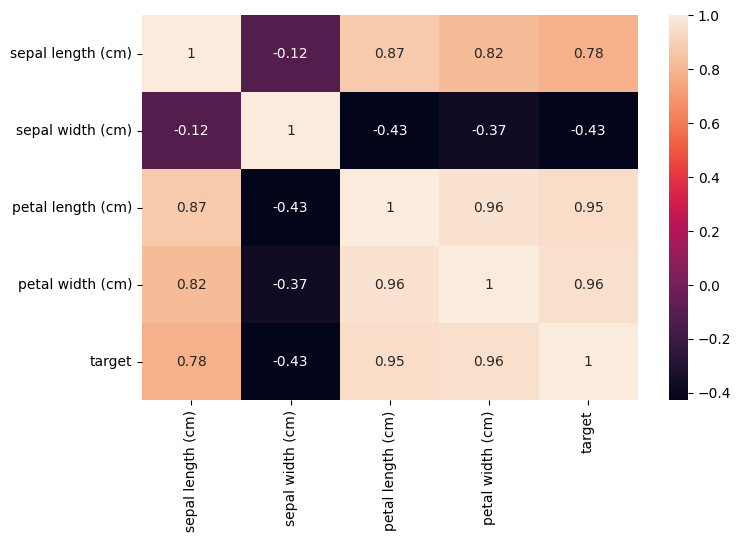

In [8]:
plt.figure(figsize=(8,5))
sns.heatmap(data.corr(),annot=True)
plt.show()

In [9]:
data=shuffle(data)
X=data[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']]
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
12,4.8,3.0,1.4,0.1
74,6.4,2.9,4.3,1.3
81,5.5,2.4,3.7,1.0
37,4.9,3.6,1.4,0.1
115,6.4,3.2,5.3,2.3
...,...,...,...,...
51,6.4,3.2,4.5,1.5
48,5.3,3.7,1.5,0.2
54,6.5,2.8,4.6,1.5
128,6.4,2.8,5.6,2.1


In [10]:
target=data[['target']]
y_true=target.copy()
target

,target
12,0.0
74,1.0
81,1.0
37,0.0
115,2.0
...,...
51,1.0
48,0.0
54,1.0
128,2.0


In [11]:
X=StandardScaler().fit_transform(X)
target=LabelBinarizer().fit_transform(target)
target

array([[1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [0,

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,target,test_size=0.3,random_state=0)

In [13]:
from keras.models import Sequential
from keras.layers import Dense, Input
import numpy as np

model = Sequential()

model.add(Input(shape=(4,)))
model.add(Dense(12, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train, Y_train, epochs=120, validation_data=(X_test, Y_test))

Y_pred = np.argmax(model.predict(X_test), axis=1)

2026-03-16 19:12:34.834456: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.5720 - loss: 1.1038 - val_accuracy: 0.5778 - val_loss: 1.0976
Epoch 2/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5969 - loss: 1.0787 - val_accuracy: 0.6444 - val_loss: 1.0698
Epoch 3/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6643 - loss: 1.0403 - val_accuracy: 0.6444 - val_loss: 1.0450
Epoch 4/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6310 - loss: 1.0223 - val_accuracy: 0.6222 - val_loss: 1.0215
Epoch 5/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6521 - loss: 1.0006 - val_accuracy: 0.6667 - val_loss: 0.9966
Epoch 6/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6937 - loss: 0.9733 - val_accuracy: 0.7556 - val_loss: 0.9682
Epoch 7/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7201 - loss: 0.9464 - val_accuracy: 0.7556 - val_loss: 0.9381
Epoch 8/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6944 - loss: 0.9206 - val_accuracy: 0.6889 - val_loss